# Finance and Graphics Demo
## Calculate Bollinger Bands
## Graph with MatplotLib 
## Use a widget to make it interactive


In [1]:

import pandas as pd
import matplotlib.pyplot as plt 

import ipywidgets as widgets
from IPython.display import display
%matplotlib inline

In [2]:
try:
    import yfinance as yf
except: 
    !pip install yfinance
    import yfinance as yf 


## Let's download a stocks Dataset


In [11]:
# Define the tickers for multiple stocks
tickers = ["AAPL", "GOOG", "AMZN", "META", "NVDA", "MSFT"]

# Download historical data for the past 5 years
stock_data = yf.download(tickers, start="2019-01-01", end="2026-02-19", group_by="ticker")

# Save the data to a CSV file (optional)
stock_data.to_csv("stock_data.csv")

# Display the first few rows
stock_data

/var/folders/wx/mgl11c114vv7vpz1f_b7szwr0000gn/T/ipykernel_63041/985042526.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(tickers, start="2019-01-01", end="2026-02-19", group_by="ticker")
[*********************100%***********************]  6 of 6 completed


Ticker            AMZN                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2019-01-02   73.260002   77.667999   73.046501   76.956497  159662000   
2019-01-03   76.000504   76.900002   74.855499   75.014000  139512000   
2019-01-04   76.500000   79.699997   75.915497   78.769501  183652000   
2019-01-07   80.115501   81.727997   79.459503   81.475502  159864000   
2019-01-08   83.234497   83.830498   80.830498   82.829002  177628000   
...                ...         ...         ...         ...        ...   
2026-02-11  208.059998  208.570007  202.490005  204.080002   65545500   
2026-02-12  203.960007  203.960007  197.559998  199.600006   83975400   
2026-02-13  198.880005  201.160004  197.279999  198.789993   66321600   
2026-02-17  198.130005  201.740005  196.000000  201.149994   69879200   
2026-02-18  202.070007  206.860001  201.509995  204.789993   51003300   

Ticker            GOOG                                                ...  \
Price             Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2019-01-02   50.450111   52.224307   50.407432   51.903214  30652000  ...   
2019-01-03   51.662515   52.455567   50.326039   50.424801  36822000  ...   
2019-01-04   51.245154   53.143415   50.988477   53.136963  41878000  ...   
2019-01-07   53.176169   53.300238   52.345398   53.021824  39638000  ...   
2019-01-08   53.404955   53.824311   52.631755   53.413391  35298000  ...   
...                ...         ...         ...         ...       ...  ...   
2026-02-11  318.959991  321.045013  310.130005  311.329987  24008100  ...   
2026-02-12  312.350006  316.480011  308.149994  309.369995  28194000  ...   
2026-02-13  307.984985  308.890015  303.899994  306.019989  20236000  ...   
2026-02-17  300.640015  304.890015  296.899994  302.820007  23750800  ...   
2026-02-18  302.432007  305.910004  301.980011  303.940002  15847700  ...   

Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2019-01-02   93.143630   95.202049   92.572885   94.612595  35329300   
2019-01-03   93.658240   93.742451   90.944863   91.131996  42579100   
2019-01-04   93.302705   95.913160   92.563543   95.370483  44060600   
2019-01-07   95.099156   96.624258   94.481633   95.492126  35656100   
2019-01-08   96.409047   97.279199   95.164635   96.184494  31514400   
...                ...         ...         ...         ...       ...   
2026-02-11  416.179993  416.459991  401.010010  404.369995  42491000   
2026-02-12  405.000000  406.200012  398.010010  401.839996  40802400   
2026-02-13  404.450012  405.540009  398.049988  401.320007  34091600   
2026-02-17  399.220001  400.519989  394.529999  396.859985  32078800   
2026-02-18  398.130005  402.559998  396.320007  399.600006  23223400   

Ticker            AAPL                                                 
Price             Open        High         Low       Close     Volume  
Date                                                                   
2019-01-02   36.784146   37.724590   36.627404   37.503727  148158800  
2019-01-03   34.193175   34.606402   33.722955   33.768078  365248800  
2019-01-04   34.323786   35.278479   34.150423   35.209606  234428400  
2019-01-07   35.314117   35.344992   34.649157   35.131252  219111200  
2019-01-08   35.518348   36.055068   35.271365   35.800957  164101200  
...                ...         ...         ...         ...        ...  
2026-02-11  274.700012  280.179993  274.450012  275.500000   51931300  
2026-02-12  275.589996  275.720001  260.179993  261.730011   81077200  
2026-02-13  262.010010  262.230011  255.449997  255.779999   56290700  
2026-02-17  258.049988  2

In [12]:
# Extract AAPL data
ap_prices = stock_data['AAPL'].copy()
ap_prices

Price,Open,High,Low,Close,Volume
Date,,,,,
2019-01-02,36.784146,37.724590,36.627404,37.503727,148158800
2019-01-03,34.193175,34.606402,33.722955,33.768078,365248800
2019-01-04,34.323786,35.278479,34.150423,35.209606,234428400
2019-01-07,35.314117,35.344992,34.649157,35.131252,219111200
2019-01-08,35.518348,36.055068,35.271365,35.800957,164101200
...,...,...,...,...,...
2026-02-11,274.700012,280.179993,274.450012,275.500000,51931300
2026-02-12,275.589996,275.720001,260.179993,261.730011,81077200
2026-02-13,262.010010,262.230011,255.449997,255.779999,56290700


# Bollinger Bands Explained

Bollinger Bands are a **technical analysis tool** used to measure market volatility and identify overbought or oversold conditions. They consist of three lines:

1. **Middle Band** – A simple moving average (SMA), typically a **20-day SMA**.
2. **Upper Band** – The SMA plus **2 standard deviations**.
3. **Lower Band** – The SMA minus **2 standard deviations**.

Since standard deviation measures volatility, the bands expand when the market is volatile and contract when the market is stable.

---

## **Formula for Bollinger Bands**
Given a time period \( N \) (typically 20 days):

- **Middle Band (SMA)**:  
  $$ \text{SMA} = \frac{1}{N} \sum_{i=1}^{N} P_i $$  
  where \( P_i \) is the price at day \( i \).

- **Upper Band**:  
  $$ \text{Upper Band} = \text{SMA} + (k \times \sigma) $$

- **Lower Band**:  
  $$ \text{Lower Band} = \text{SMA} - (k \times \sigma) $$
where:
-  $\sigma $ is the standard deviation of prices over $ N $ days.
- $k$ is typically **2**, meaning bands are **2 standard deviations** from the SMA.

---

## **How to Interpret Bollinger Bands**
1. **Price Near the Upper Band → Overbought**
   - If the price touches or moves above the upper band, the asset **may be overbought**, signaling a possible reversal downward.

2. **Price Near the Lower Band → Oversold**
   - If the price touches or moves below the lower band, the asset **may be oversold**, signaling a possible upward reversal.

3. **Bollinger Band Squeeze → Low Volatility**
   - When bands contract, it signals **low volatility** and often precedes a breakout in either direction.

4. **Bollinger Band Expansion → High Volatility**
   - When bands widen, volatility is increasing. This often happens after a strong move in price.

---


## Calculate the new Bollinger Bands columns
`Pandas` has a `.rolling` argument that we can pass in

In [13]:
window = 20  

In [14]:
ap_prices['SMA'] = ap_prices['Close'].rolling(window).mean()  # Simple Moving Average
ap_prices['StdDev'] = ap_prices['Close'].rolling(window).std()  # Standard Deviation
ap_prices['Upper'] = ap_prices['SMA'] + (2 * ap_prices['StdDev'])  # Upper Band
ap_prices['Lower'] = ap_prices['SMA'] - (2 * ap_prices['StdDev'])  # Lower Band

In [15]:
ap_prices = ap_prices.dropna()
ap_prices

Price,Open,High,Low,Close,Volume,SMA,StdDev,Upper,Lower
Date,,,,,,,,,
2019-01-30,38.769524,39.458231,38.052317,39.244495,244439200,36.466509,1.106463,38.679434,34.253584
2019-01-31,39.448725,40.135058,39.080622,39.527096,162958400,36.567677,1.284474,39.136625,33.998729
2019-02-01,39.650595,40.130313,39.405981,39.546101,130672400,36.856578,1.271377,39.399332,34.313825
2019-02-04,39.757467,40.766781,39.726593,40.669411,125982000,37.129569,1.469806,40.069181,34.189956
2019-02-05,41.051763,41.578981,40.930647,41.365242,144406400,37.441268,1.670972,40.783212,34.099324
...,...,...,...,...,...,...,...,...,...
2026-02-11,274.700012,280.179993,274.450012,275.500000,51931300,262.099789,10.916913,283.933616,240.265963
2026-02-12,275.589996,275.720001,260.179993,261.730011,81077200,262.200441,10.903059,284.006559,240.394322
2026-02-13,262.010010,262.230011,255.449997,255.779999,56290700,262.091011,10.958610,284.008230,240.173792


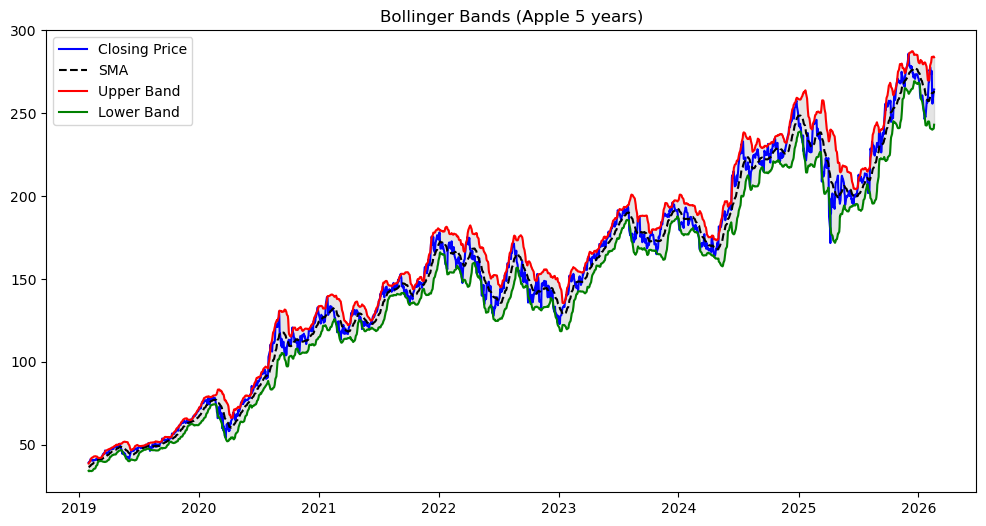

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(ap_prices.index, ap_prices['Close'], label="Closing Price", color='blue')
plt.plot(ap_prices.index, ap_prices['SMA'], label="SMA", color='black', linestyle="dashed")
plt.plot(ap_prices.index, ap_prices['Upper'], label="Upper Band", color='red')
plt.plot(ap_prices.index, ap_prices['Lower'], label="Lower Band", color='green')
plt.fill_between(ap_prices.index, ap_prices['Upper'], ap_prices['Lower'], color='gray', alpha=0.2)
plt.title("Bollinger Bands (Apple 5 years)")
plt.legend()
plt.show()

In [37]:
# Filter the data to only include the last year
last_year = ap_prices.loc[ap_prices.index >= ap_prices.index.max() - pd.DateOffset(years=1)].copy()


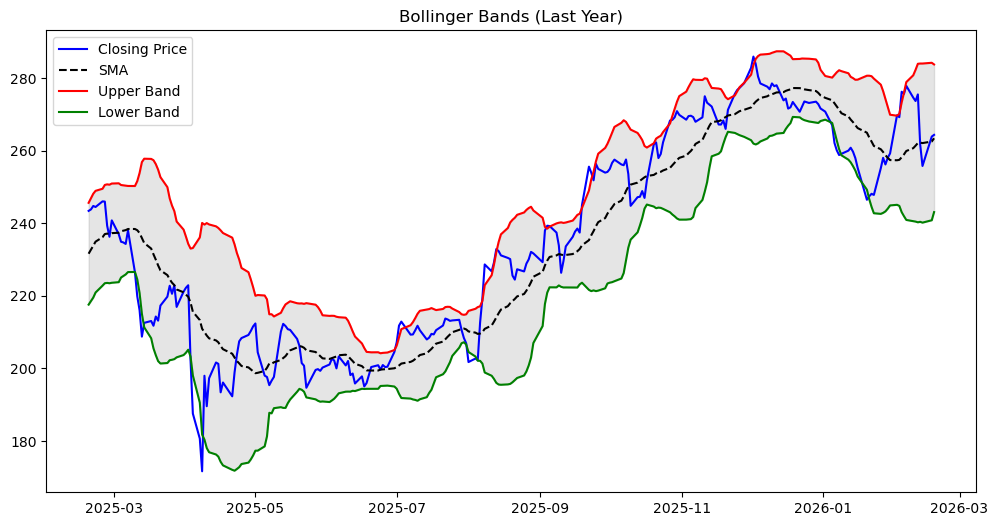

In [38]:
# Plot Bollinger Bands for the last year
plt.figure(figsize=(12, 6))
plt.plot(last_year.index, last_year['Close'], label="Closing Price", color='blue')
plt.plot(last_year.index, last_year['SMA'], label="SMA", color='black', linestyle="dashed")
plt.plot(last_year.index, last_year['Upper'], label="Upper Band", color='red')
plt.plot(last_year.index, last_year['Lower'], label="Lower Band", color='green')

# Fill the area between the upper and lower bands
plt.fill_between(last_year.index, last_year['Upper'].values, last_year['Lower'].values, color='gray', alpha=0.2)

plt.title("Bollinger Bands (Last Year)")
plt.legend()
plt.show()

## Identify overbought conditions where the closing price is above the upper Bollinger Band

In [39]:
overbought = last_year[last_year['Close'] > last_year['Upper']]

overbought

# add oversold
oversold = last_year[last_year['Close'] < last_year['Lower']]

oversold

Price,Open,High,Low,Close,Volume,SMA,StdDev,Upper,Lower
Date,,,,,,,,,
2025-03-10,234.517865,235.135185,223.246996,226.492844,72071200,238.421354,5.920216,250.261787,226.580921
2025-03-11,222.838766,224.859955,216.506364,219.881653,76137400,238.082332,6.763182,251.608695,224.555968
2025-03-12,219.184697,220.787711,213.977397,216.038406,62547500,237.303725,8.274876,253.853477,220.753974
2025-03-13,215.012876,215.899013,207.515554,208.770081,61368300,235.950125,10.453873,256.857871,215.042380
2025-04-03,204.648036,206.589586,200.376659,202.308243,103419000,218.149216,7.438967,233.027149,203.271282
2025-04-04,193.048614,199.012626,186.527035,187.562531,125910900,215.625714,8.778751,233.183216,198.068212
2025-04-07,176.431038,193.307481,173.862232,180.672562,160466300,213.334700,11.385393,236.105486,190.563914
2025-04-08,185.889798,189.514001,168.475707,171.671768,120859500,210.924206,14.581250,240.086705,181.761706
2025-08-01,210.230255,212.932040,200.888687,201.766022,104434500,210.197852,2.832382,215.862616,204.533087


### Plot Bollinger Bands with overbought conditions highlighted


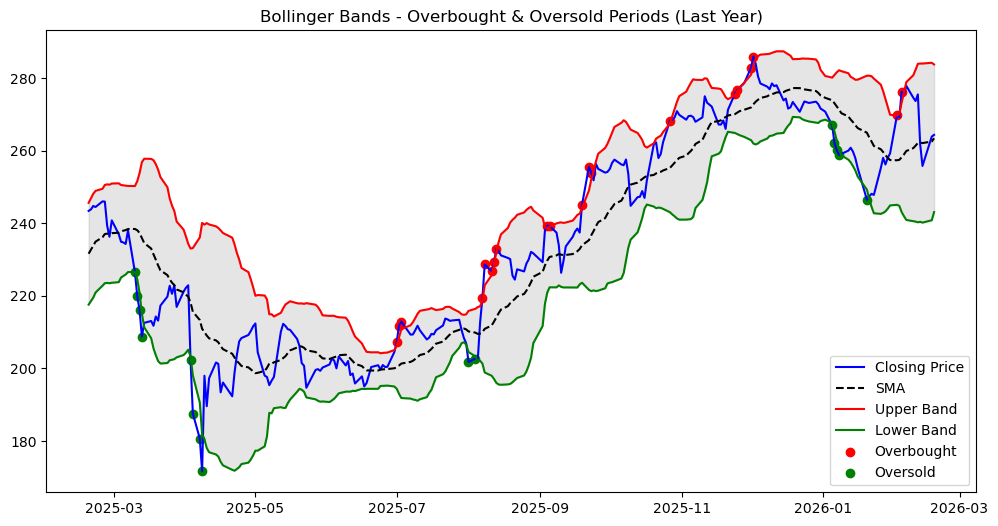

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(last_year.index, last_year['Close'], label="Closing Price", color='blue')
plt.plot(last_year.index, last_year['SMA'], label="SMA", color='black', linestyle="dashed")
plt.plot(last_year.index, last_year['Upper'], label="Upper Band", color='red')
plt.plot(last_year.index, last_year['Lower'], label="Lower Band", color='green')

# Fill the Bollinger Bands range
plt.fill_between(last_year.index, last_year['Upper'].values, last_year['Lower'].values, color='gray', alpha=0.2)

# Highlight overbought points
plt.scatter(overbought.index, overbought['Close'], color='red', label="Overbought", marker='o')

# Highlight oversold points
plt.scatter(oversold.index, oversold['Close'], color='green', label="Oversold", marker='o')

plt.title("Bollinger Bands - Overbought & Oversold Periods (Last Year)")
plt.legend()
plt.show()

## Lets build some widgets!

In [41]:
tickers

['AAPL', 'GOOG', 'AMZN', 'META', 'NVDA', 'MSFT']

In [42]:
# Create dropdown for stock selection
stock_picker = widgets.Dropdown(
    options=tickers,
    value="AAPL",
    description="Stock:"
)

# Create slider for selecting the time window in years
time_window = widgets.IntSlider(
    value=1,  # Default to 1 year
    min=1,
    max=5,
    step=1,
    description="Years:"
)



# Create slider for MA window size
ma_window = widgets.IntSlider(
    value=20,  # Default to 20 days
    min=5,
    max=50,
    step=5,
    description="MA Window:"
)

In [28]:
# Display widgets
display(stock_picker, time_window, ma_window)

Dropdown(description='Stock:', options=('AAPL', 'GOOG', 'AMZN', 'META', 'NVDA', 'MSFT'), value='AAPL')

IntSlider(value=1, description='Years:', max=5, min=1)

IntSlider(value=20, description='MA Window:', min=5, step=5)

## Lets make the Graph again but lets let it update with the widgets

- put the whole graph in a function 
- fuction takes 3 arguments which are the widgets
- plot it and have it update as widgets change


In [44]:
# Function to compute and plot Bollinger Bands
def plot_bollinger_bands(stock, years, window=20):
    # Extract only the selected stock's data
    df = stock_data[stock].copy()
    
    # Get the last date in the dataset and compute the start date
    end_date = df.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    
    # Filter data based on the selected time window
    df = df.loc[start_date:end_date]

    # Compute Bollinger Bands
    df['SMA'] = df['Close'].rolling(window).mean()
    df['StdDev'] = df['Close'].rolling(window).std()
    df['Upper'] = df['SMA'] + (2 * df['StdDev'])
    df['Lower'] = df['SMA'] - (2 * df['StdDev'])

    # Drop NaN values
    df = df.dropna()

    # Plot Bollinger Bands
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Close'], label="Closing Price", color='blue')
    plt.plot(df.index, df['SMA'], label="SMA", color='black', linestyle="dashed")
    plt.plot(df.index, df['Upper'], label="Upper Band", color='red')
    plt.plot(df.index, df['Lower'], label="Lower Band", color='green')
    plt.fill_between(df.index, df['Upper'], df['Lower'], color='gray', alpha=0.2)

    plt.title(f"Bollinger Bands for {stock} ({years} Year(s), MA={window})")
    plt.legend()
    plt.show()



In [45]:
# Create an interactive widget with output
output = widgets.Output()

# Function to update the output widget
def update_plot(stock, years, window):
    with output:
        output.clear_output(wait=True)
        plot_bollinger_bands(stock, years, window)

# Create interactive widgets
interactive_plot = widgets.interactive(update_plot, stock=stock_picker, years=time_window, window=ma_window)

# Display widgets and output
display(stock_picker, time_window, ma_window, output)

# Call the function once to display initial plot
update_plot(stock_picker.value, time_window.value, ma_window.value)

Dropdown(description='Stock:', options=('AAPL', 'GOOG', 'AMZN', 'META', 'NVDA', 'MSFT'), value='AAPL')

IntSlider(value=1, description='Years:', max=5, min=1)

IntSlider(value=20, description='MA Window:', max=50, min=5, step=5)

Output()

## Can we make a trading rule 
- buy when oversold for 2 days 
- sell when overbought 2 days

## When would trades get made?

In [46]:
# Create signals for oversold and overbought conditions
last_year['oversold_signal'] = (last_year['Close'] < last_year['Lower']).astype(int)
last_year['overbought_signal'] = (last_year['Close'] > last_year['Upper']).astype(int)

# Check for 2 consecutive days of oversold/overbought
# Rolling sum of 2 periods - if it equals 2, then we had 2 consecutive days
last_year['oversold_2days'] = last_year['oversold_signal'].rolling(2).sum() == 2
last_year['overbought_2days'] = last_year['overbought_signal'].rolling(2).sum() == 2

last_year[['Close', 'Lower', 'Upper', 'oversold_signal', 'overbought_signal', 'oversold_2days', 'overbought_2days']].tail(20)

Price,Close,Lower,Upper,oversold_signal,overbought_signal,oversold_2days,overbought_2days
Date,,,,,,,
2026-01-21,247.418488,246.651601,280.650984,0,0,False,False
2026-01-22,248.117844,244.524080,280.518621,0,0,False,False
2026-01-23,247.808121,242.761288,279.851688,0,0,False,False
2026-01-26,255.171234,242.590932,278.183765,0,0,False,False
2026-01-27,258.028534,242.862027,276.401083,0,0,False,False
2026-01-28,256.200287,243.273505,274.259225,0,0,False,False
2026-01-29,258.038544,244.018807,272.035307,0,0,False,False
2026-01-30,259.237427,244.914171,269.903102,0,0,False,False
2026-02-02,269.757599,245.082838,269.634530,0,1,False,False


In [48]:
# Generate trading signals
# Buy signal: When we hit 2 consecutive oversold days (day 2 of the signal)
# Sell signal: When we hit 2 consecutive overbought days (day 2 of the signal)

# Shift to ensure we're only counting the transition into the 2-day period
last_year['buy_signal'] = last_year['oversold_2days'] & ~last_year['oversold_2days'].shift(1, fill_value=False)
last_year['sell_signal'] = last_year['overbought_2days'] & ~last_year['overbought_2days'].shift(1, fill_value=False)

# Get the dates when trades would be made
buy_dates = last_year[last_year['buy_signal']]
sell_dates = last_year[last_year['sell_signal']]

print(f"Number of BUY signals: {len(buy_dates)}")
print(f"Number of SELL signals: {len(sell_dates)}")
print("\nBuy signals:")
print(buy_dates[['Close', 'Lower', 'Upper']])
print("\nSell signals:")
print(sell_dates[['Close', 'Lower', 'Upper']])

Number of BUY signals: 4
Number of SELL signals: 6

Buy signals:
Price            Close       Lower       Upper
Date                                          
2025-03-11  219.881653  224.555968  251.608695
2025-04-04  187.562531  198.068212  233.183216
2025-08-04  202.733078  203.296175  216.441533
2026-01-06  262.114716  265.267204  280.866762

Sell signals:
Price            Close       Lower       Upper
Date                                          
2025-07-02  211.795486  193.006517  208.614315
2025-08-08  228.654190  198.883641  222.930748
2025-09-05  239.234009  222.356389  239.070122
2025-09-22  255.592819  221.645395  249.031485
2025-11-25  276.711090  264.570682  276.368066
2025-12-02  285.922455  261.949907  283.606169


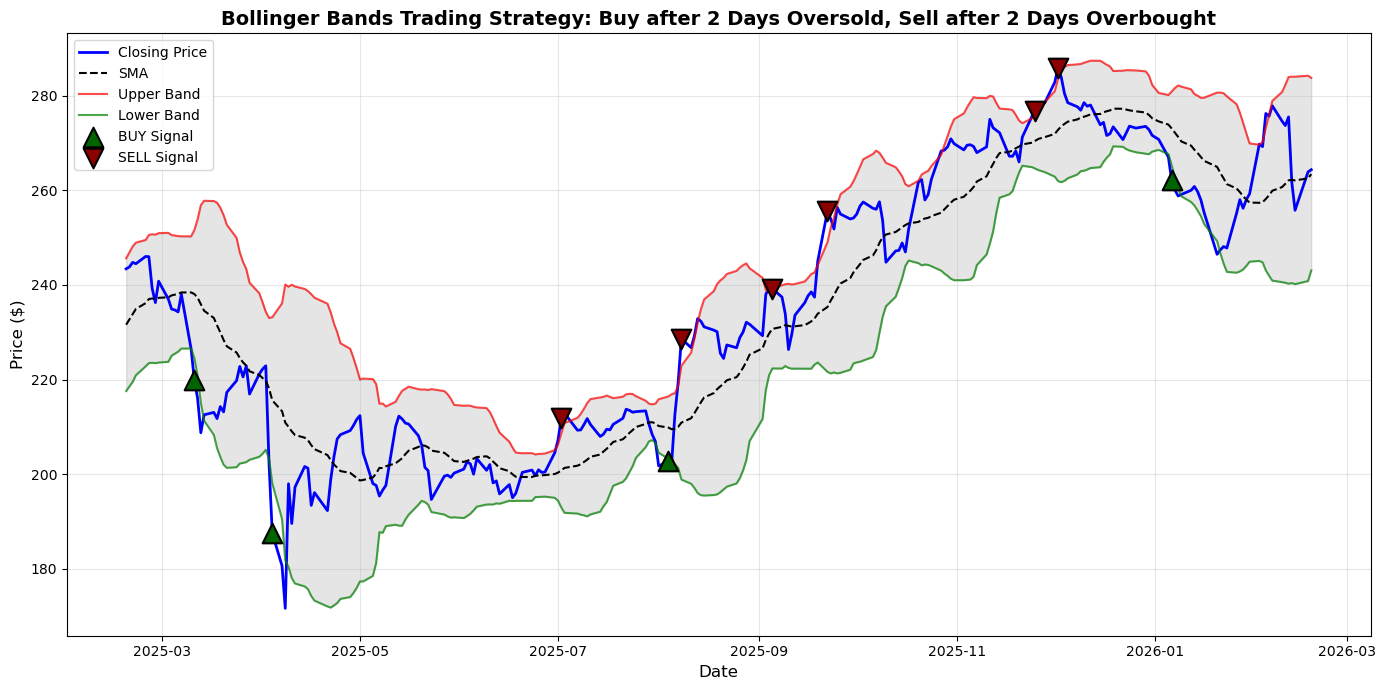

In [49]:
# Visualize the trading signals on the Bollinger Bands chart
plt.figure(figsize=(14, 7))

# Plot Bollinger Bands
plt.plot(last_year.index, last_year['Close'], label="Closing Price", color='blue', linewidth=2)
plt.plot(last_year.index, last_year['SMA'], label="SMA", color='black', linestyle="dashed")
plt.plot(last_year.index, last_year['Upper'], label="Upper Band", color='red', alpha=0.7)
plt.plot(last_year.index, last_year['Lower'], label="Lower Band", color='green', alpha=0.7)
plt.fill_between(last_year.index, last_year['Upper'].values, last_year['Lower'].values, color='gray', alpha=0.2)

# Mark BUY signals (green triangles pointing up)
if len(buy_dates) > 0:
    plt.scatter(buy_dates.index, buy_dates['Close'], color='darkgreen', marker='^', 
                s=200, label="BUY Signal", zorder=5, edgecolors='black', linewidth=1.5)

# Mark SELL signals (red triangles pointing down)
if len(sell_dates) > 0:
    plt.scatter(sell_dates.index, sell_dates['Close'], color='darkred', marker='v', 
                s=200, label="SELL Signal", zorder=5, edgecolors='black', linewidth=1.5)

plt.title("Bollinger Bands Trading Strategy: Buy after 2 Days Oversold, Sell after 2 Days Overbought", 
          fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Trading Strategy Performance

Let's calculate a simple returns analysis:
- Assume we buy at the close price on a buy signal
- Assume we sell at the close price on a sell signal
- Calculate the return for each buy-sell pair

In [51]:
# Simple trading performance calculation
# Match each buy with the next sell signal

if len(buy_dates) > 0 and len(sell_dates) > 0:
    trades = []
    
    for buy_date in buy_dates.index:
        # Find the next sell signal after this buy
        future_sells = sell_dates[sell_dates.index > buy_date]
        
        if len(future_sells) > 0:
            sell_date = future_sells.index[0]
            buy_price = buy_dates.loc[buy_date, 'Close']
            sell_price = sell_dates.loc[sell_date, 'Close']
            
            profit = sell_price - buy_price
            return_pct = (profit / buy_price) * 100
            
            trades.append({
                'Buy Date': buy_date,
                'Buy Price': buy_price,
                'Sell Date': sell_date,
                'Sell Price': sell_price,
                'Profit ($)': profit,
                'Return (%)': return_pct
            })
    
    trades_df = pd.DataFrame(trades)
    print(f"\nTotal number of completed trades: {len(trades_df)}")
    print(f"Average return per trade: {trades_df['Return (%)'].mean():.2f}%")
    print(f"Total profit: ${trades_df['Profit ($)'].sum():.2f}\n")
    print(trades_df)
else:
    print("Not enough buy/sell signals to calculate performance")


Total number of completed trades: 3
Average return per trade: 7.34%
Total profit: $42.07

    Buy Date   Buy Price  Sell Date  Sell Price  Profit ($)  Return (%)
0 2025-03-11  219.881653 2025-07-02  211.795486   -8.086166   -3.677508
1 2025-04-04  187.562531 2025-07-02  211.795486   24.232956   12.919934
2 2025-08-04  202.733078 2025-08-08  228.654190   25.921112   12.785833


### Compare to Buy-and-Hold Strategy

Let's compare the trading strategy to simply buying at the beginning and holding until the end.

In [ ]:
# Calculate Buy-and-Hold performance for the same period
buy_hold_start_price = last_year['Close'].iloc[0]
buy_hold_end_price = last_year['Close'].iloc[-1]
buy_hold_profit = buy_hold_end_price - buy_hold_start_price
buy_hold_return = (buy_hold_profit / buy_hold_start_price) * 100

print("=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)
print(f"\n📊 BUY-AND-HOLD STRATEGY:")
print(f"   Start Date: {last_year.index[0].strftime('%Y-%m-%d')}")
print(f"   End Date: {last_year.index[-1].strftime('%Y-%m-%d')}")
print(f"   Buy Price: ${buy_hold_start_price:.2f}")
print(f"   End Price: ${buy_hold_end_price:.2f}")
print(f"   Total Return: {buy_hold_return:.2f}%")
print(f"   Total Profit: ${buy_hold_profit:.2f}")

if len(buy_dates) > 0 and len(sell_dates) > 0 and len(trades_df) > 0:
    trading_total_return = trades_df['Return (%)'].sum()
    trading_total_profit = trades_df['Profit ($)'].sum()
    
    print(f"\n📈 BOLLINGER TRADING STRATEGY:")
    print(f"   Number of Trades: {len(trades_df)}")
    print(f"   Average Return per Trade: {trades_df['Return (%)'].mean():.2f}%")
    print(f"   Total Return: {trading_total_return:.2f}%")
    print(f"   Total Profit: ${trading_total_profit:.2f}")
    
    print(f"\n{'='*60}")
    print("COMPARISON:")
    print(f"{'='*60}")
    
    if trading_total_return > buy_hold_return:
        outperformance = trading_total_return - buy_hold_return
        print(f"✅ Trading Strategy OUTPERFORMED by {outperformance:.2f}%")
    else:
        underperformance = buy_hold_return - trading_total_return
        print(f"❌ Trading Strategy UNDERPERFORMED by {underperformance:.2f}%")
    
    profit_diff = trading_total_profit - buy_hold_profit
    if profit_diff > 0:
        print(f"   Extra profit: ${profit_diff:.2f}")
    else:
        print(f"   Less profit: ${abs(profit_diff):.2f}")
else:
    print("\n⚠️  Not enough trading signals to compare strategies")

In [ ]:
# Visualize the comparison
if len(buy_dates) > 0 and len(sell_dates) > 0 and len(trades_df) > 0:
    strategies = ['Buy & Hold', 'Bollinger Trading']
    returns = [buy_hold_return, trades_df['Return (%)'].sum()]
    colors = ['skyblue', 'lightcoral']
    
    # Determine which is better and adjust colors
    if returns[1] > returns[0]:
        colors[1] = 'lightgreen'
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(strategies, returns, color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, ret in zip(bars, returns):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{ret:.2f}%',
                ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    ax.set_ylabel('Total Return (%)', fontsize=12)
    ax.set_title('Strategy Performance Comparison (Last Year)', fontsize=14, fontweight='bold')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()